# Colab E — TensorFlow Variants: 3-Layer Deep NN for Non-Linear Regression

**CMPE 258 — Deep Learning | Spring 2026 | San José State University**

**Author:** Parth  
**Instructor:** Vijay Eranti

---

## Overview

This notebook implements the **same 3-hidden-layer neural network** using **three different TensorFlow API levels**:

| Section | API Level | Description |
|---------|-----------|-------------|
| **Part (i)** | Low-level `tf.Variable` + `tf.GradientTape` | From scratch, no Keras |
| **Part (ii)** | `tf.keras.Sequential` with built-in layers | Standard Keras workflow |
| **Part (iii)** | `tf.keras.functional` API | Multi-input/output capable |

### Same architecture across all parts:
```
Input(3) → Dense(64, relu) → Dense(32, tanh) → Dense(16, relu) → Dense(1, linear)
```

### Same equation:
$$y = 3x_1^2 + 2\sin(\pi x_2) \cdot x_3 - x_3^3 + 0.5 x_1 x_2 + 1$$

## 0. Environment & Data Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


In [2]:
# --- Shared Synthetic Data (used by all 3 parts) ---
n_samples = 500
X_np = np.random.uniform(-1, 1, (n_samples, 3)).astype(np.float32)
x1, x2, x3 = X_np[:, 0:1], X_np[:, 1:2], X_np[:, 2:3]

y_np = (3.0 * x1**2
        + 2.0 * np.sin(np.pi * x2) * x3
        - x3**3
        + 0.5 * x1 * x2
        + 1.0).astype(np.float32)

# PCA for visualization (computed once)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_np))

print(f'X: {X_np.shape}  |  y: {y_np.shape}')


# --- Shared plotting utility ---
def plot_results(y_true, y_pred, title_prefix):
    """Standardized result plots for each TF variant."""
    y_pred = np.array(y_pred).reshape(-1, 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Predicted vs True
    axes[0].scatter(y_true, y_pred, alpha=0.4, s=10, color='coral')
    lims = [y_true.min(), y_true.max()]
    axes[0].plot(lims, lims, 'k--', lw=1.5)
    axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'{title_prefix}: Pred vs True')

    # PCA
    sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred.flatten(),
                         cmap='viridis', alpha=0.7, s=15)
    axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
    axes[1].set_title(f'{title_prefix}: PCA (color=pred)')
    plt.colorbar(sc, ax=axes[1])

    # Residuals
    residuals = (y_true - y_pred).flatten()
    axes[2].hist(residuals, bins=40, color='teal', alpha=0.7, edgecolor='white')
    axes[2].axvline(0, color='red', linestyle='--')
    axes[2].set_title(f'Residuals (std={residuals.std():.4f})')

    plt.tight_layout(); plt.show()

    # R²
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    print(f'{title_prefix} R² score: {1 - ss_res/ss_tot:.4f}')

X: (500, 3)  |  y: (500, 1)


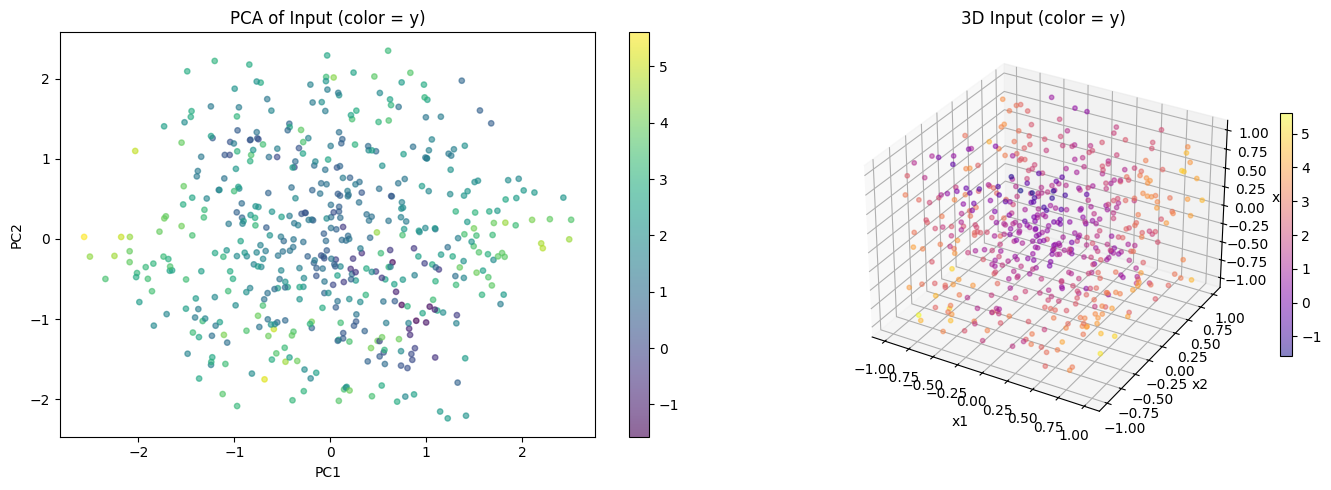

In [3]:
# --- 4D Data Visualization ---
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121)
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_np.flatten(),
                  cmap='viridis', alpha=0.6, s=15)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('PCA of Input (color = y)'); plt.colorbar(sc1, ax=ax1)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                  c=y_np.flatten(), cmap='plasma', alpha=0.5, s=10)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title('3D Input (color = y)'); plt.colorbar(sc2, ax=ax2, shrink=0.6)
plt.tight_layout(); plt.show()

---
# Part (i) — TensorFlow Low-Level API (From Scratch)

Using **only** `tf.Variable`, `tf.GradientTape`, and raw tensor operations.
**No Keras layers, no model.fit()** — everything is manual.

In [4]:
# --- Part (i): Manual weight initialization ---
def he_init(shape):
    """He initialization for a weight matrix."""
    return tf.Variable(
        tf.random.normal(shape, stddev=tf.sqrt(2.0 / shape[0])),
        dtype=tf.float32
    )

def zero_bias(shape):
    return tf.Variable(tf.zeros(shape), dtype=tf.float32)

# Layer weights (3 hidden + 1 output)
W1_i = he_init([3, 64]);   b1_i = zero_bias([1, 64])
W2_i = he_init([64, 32]);  b2_i = zero_bias([1, 32])
W3_i = he_init([32, 16]);  b3_i = zero_bias([1, 16])
W4_i = he_init([16, 1]);   b4_i = zero_bias([1, 1])

params_i = [W1_i, b1_i, W2_i, b2_i, W3_i, b3_i, W4_i, b4_i]
total = sum(tf.size(p).numpy() for p in params_i)
print(f'Part (i) total parameters: {total}')

Part (i) total parameters: 2881


In [5]:
@tf.function
def forward_scratch(X):
    """
    Manual forward pass using raw TF operations.
    Layer 1: ReLU, Layer 2: Tanh, Layer 3: ReLU, Output: Linear
    """
    z1 = tf.matmul(X, W1_i) + b1_i
    a1 = tf.nn.relu(z1)

    z2 = tf.matmul(a1, W2_i) + b2_i
    a2 = tf.nn.tanh(z2)

    z3 = tf.matmul(a2, W3_i) + b3_i
    a3 = tf.nn.relu(z3)

    out = tf.matmul(a3, W4_i) + b4_i
    return out

# Test
X_tf = tf.constant(X_np)
y_tf = tf.constant(y_np)
print(f'Forward test shape: {forward_scratch(X_tf).shape}')

Forward test shape: (500, 1)


In [6]:
# --- Part (i): Training with GradientTape ---
num_epochs = 2000
lr = 0.005
loss_history_i = []

for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        y_pred = forward_scratch(X_tf)
        loss = tf.reduce_mean((y_pred - y_tf) ** 2)

    # Compute gradients
    grads = tape.gradient(loss, params_i)

    # Manual SGD update
    for p, g in zip(params_i, grads):
        p.assign_sub(lr * g)

    loss_history_i.append(loss.numpy())

    if epoch % 200 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:4d}/{num_epochs}  |  Loss: {loss.numpy():.6f}')

print(f'\nPart (i) Final Loss: {loss_history_i[-1]:.6f}')

Epoch    0/2000  |  Loss: 6.522398
Epoch  200/2000  |  Loss: 0.337017
Epoch  400/2000  |  Loss: 0.216705
Epoch  600/2000  |  Loss: 0.170396
Epoch  800/2000  |  Loss: 0.141144
Epoch 1000/2000  |  Loss: 0.119572
Epoch 1200/2000  |  Loss: 0.103248
Epoch 1400/2000  |  Loss: 0.090999
Epoch 1600/2000  |  Loss: 0.081686
Epoch 1800/2000  |  Loss: 0.074597
Epoch 1999/2000  |  Loss: 0.068939

Part (i) Final Loss: 0.068939


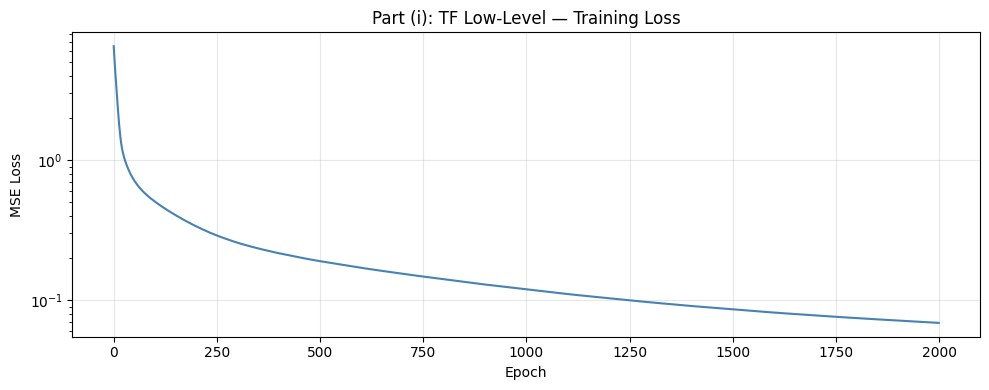

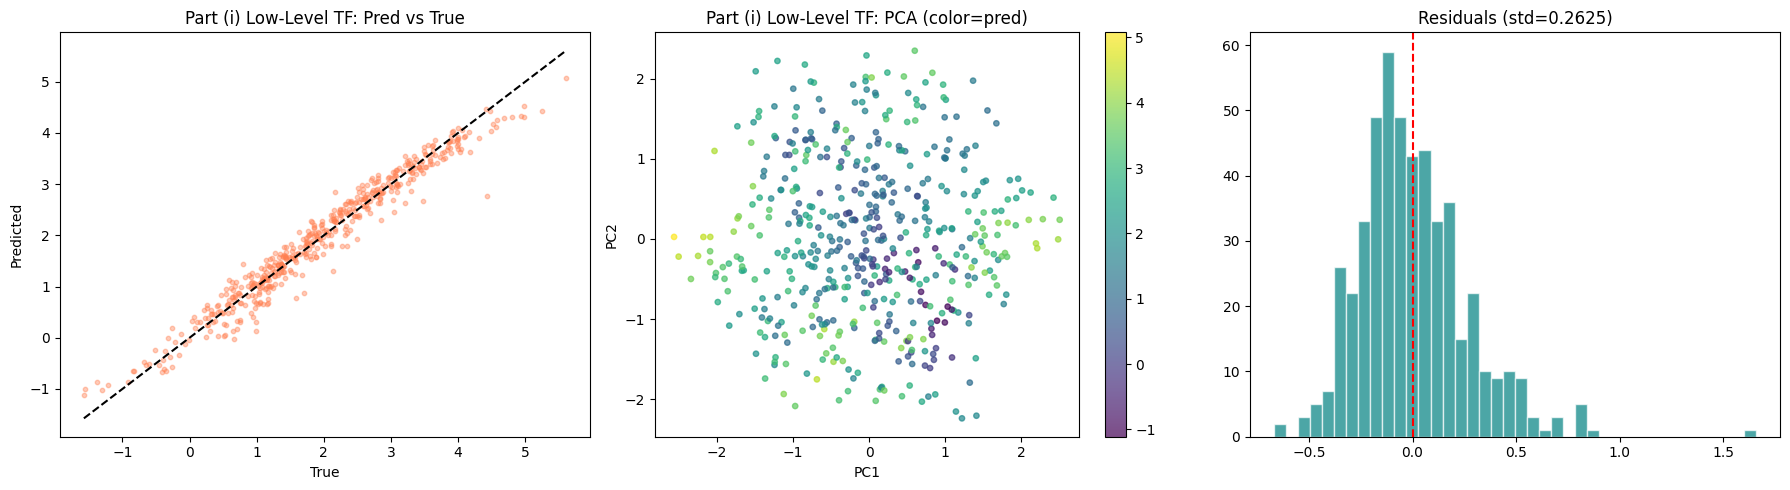

Part (i) Low-Level TF R² score: 0.9573


In [7]:
# --- Part (i): Results ---
plt.figure(figsize=(10, 4))
plt.plot(loss_history_i, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Part (i): TF Low-Level — Training Loss')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

y_pred_i = forward_scratch(X_tf).numpy()
plot_results(y_np, y_pred_i, 'Part (i) Low-Level TF')

---
# Part (ii) — TensorFlow Built-in Layers (Sequential API)

Using `tf.keras.Sequential` with `Dense` layers. This is the standard Keras workflow.

In [8]:
# --- Part (ii): Sequential model with built-in layers ---
model_seq = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_initializer='he_normal',
                          input_shape=(3,), name='hidden1'),
    tf.keras.layers.Dense(32, activation='tanh',
                          kernel_initializer='he_normal', name='hidden2'),
    tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer='he_normal', name='hidden3'),
    tf.keras.layers.Dense(1, name='output')
], name='DeepNet3Layer_Sequential')

model_seq.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

model_seq.summary()

Model: "DeepNet3Layer_Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# --- Part (ii): Train ---
history_seq = model_seq.fit(
    X_np, y_np,
    epochs=500,
    batch_size=64,
    validation_split=0.2,
    verbose=0  # silent — we'll plot instead
)

print(f'Part (ii) Final train loss: {history_seq.history["loss"][-1]:.6f}')
print(f'Part (ii) Final val loss:   {history_seq.history["val_loss"][-1]:.6f}')

Part (ii) Final train loss: 0.007404
Part (ii) Final val loss:   0.025811


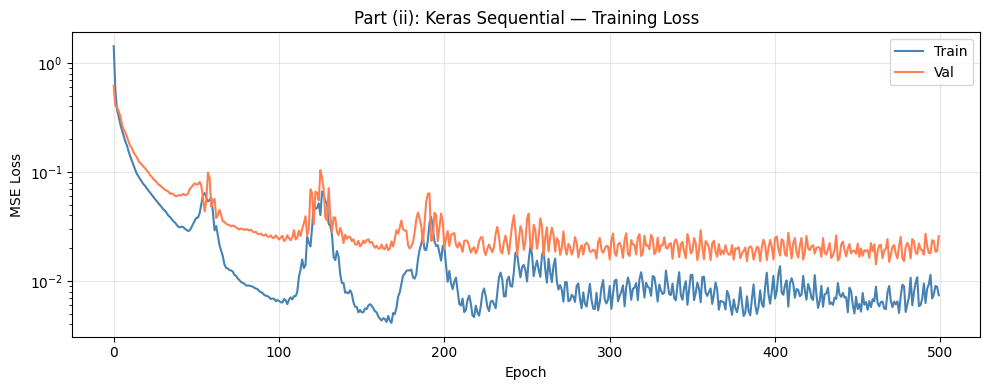

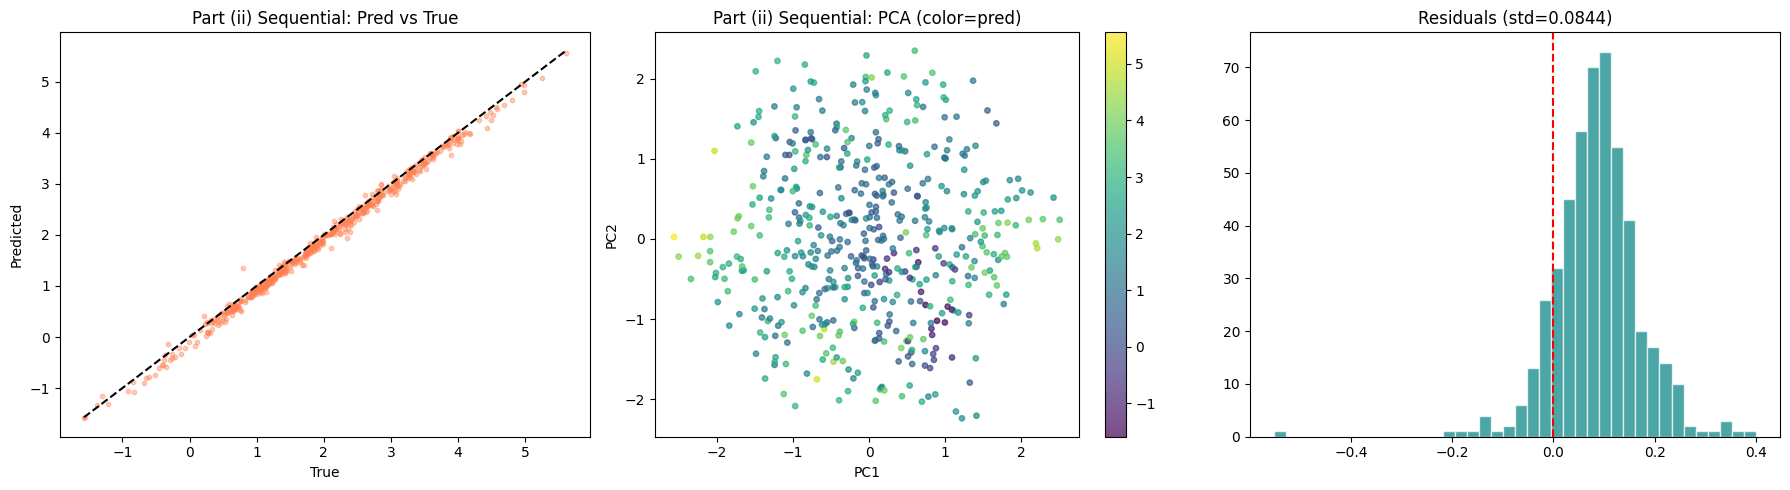

Part (ii) Sequential R² score: 0.9910


In [10]:
# --- Part (ii): Results ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_seq.history['loss'], label='Train', color='steelblue')
ax.plot(history_seq.history['val_loss'], label='Val', color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Part (ii): Keras Sequential — Training Loss')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout(); plt.show()

y_pred_ii = model_seq.predict(X_np, verbose=0)
plot_results(y_np, y_pred_ii, 'Part (ii) Sequential')

---
# Part (iii) — TensorFlow Functional API

Using `tf.keras.Input` and functional layer chaining. This API supports more complex topologies (multi-input, skip connections, etc.).

In [11]:
# --- Part (iii): Functional API model ---
inputs = tf.keras.Input(shape=(3,), name='input')

x = tf.keras.layers.Dense(64, activation='relu',
                           kernel_initializer='he_normal',
                           name='hidden1')(inputs)
x = tf.keras.layers.Dense(32, activation='tanh',
                           kernel_initializer='he_normal',
                           name='hidden2')(x)
x = tf.keras.layers.Dense(16, activation='relu',
                           kernel_initializer='he_normal',
                           name='hidden3')(x)
outputs = tf.keras.layers.Dense(1, name='output')(x)

model_func = tf.keras.Model(inputs=inputs, outputs=outputs,
                             name='DeepNet3Layer_Functional')

model_func.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

model_func.summary()

Model: "DeepNet3Layer_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# --- Part (iii): Train ---
history_func = model_func.fit(
    X_np, y_np,
    epochs=500,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

print(f'Part (iii) Final train loss: {history_func.history["loss"][-1]:.6f}')
print(f'Part (iii) Final val loss:   {history_func.history["val_loss"][-1]:.6f}')

Part (iii) Final train loss: 0.007017
Part (iii) Final val loss:   0.018135


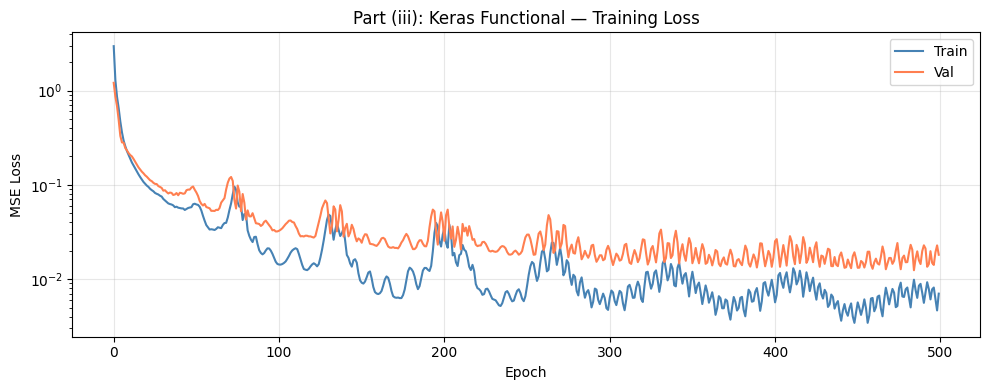

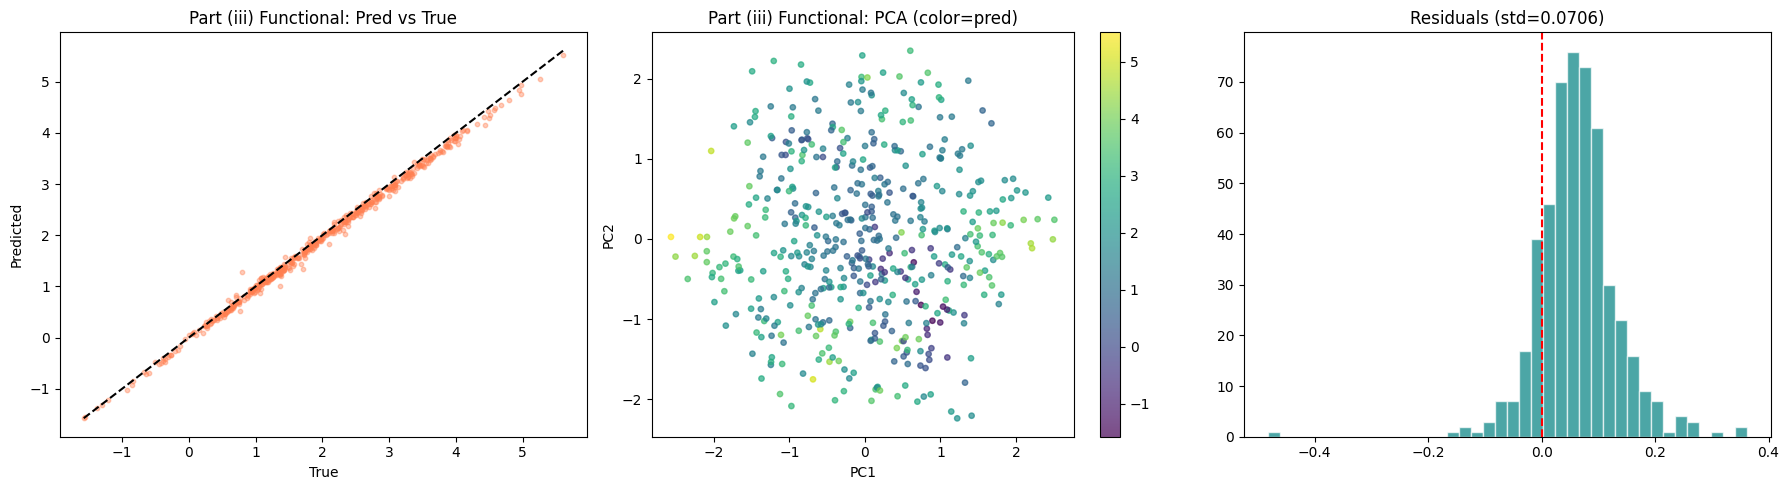

Part (iii) Functional R² score: 0.9944


In [13]:
# --- Part (iii): Results ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_func.history['loss'], label='Train', color='steelblue')
ax.plot(history_func.history['val_loss'], label='Val', color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Part (iii): Keras Functional — Training Loss')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout(); plt.show()

y_pred_iii = model_func.predict(X_np, verbose=0)
plot_results(y_np, y_pred_iii, 'Part (iii) Functional')

---
## Comparison of All Three TF Variants

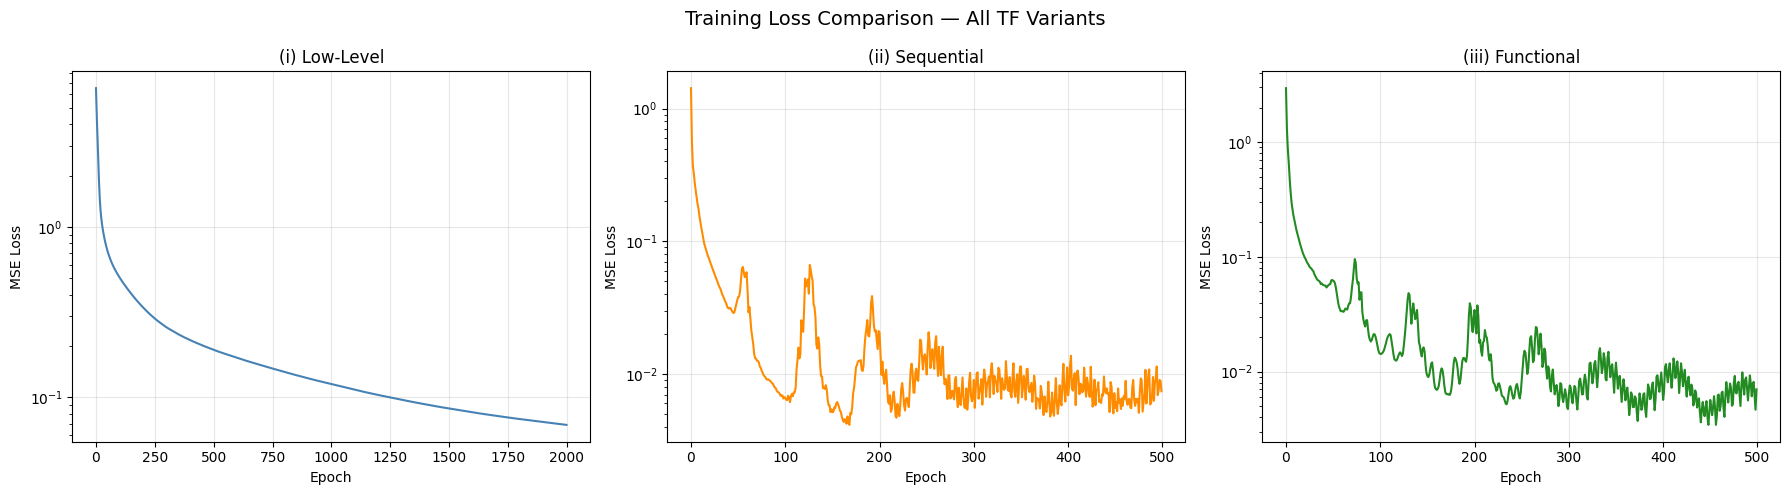

(i) Low-Level R²: 0.9573
(ii) Sequential R²: 0.9910
(iii) Functional R²: 0.9944


In [14]:
# --- Side-by-side comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variants = [
    ('(i) Low-Level', loss_history_i),
    ('(ii) Sequential', history_seq.history['loss']),
    ('(iii) Functional', history_func.history['loss']),
]
colors = ['steelblue', 'darkorange', 'forestgreen']

for ax, (name, losses), color in zip(axes, variants, colors):
    ax.plot(losses, color=color, linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title(name)
    ax.grid(True, alpha=0.3); ax.set_yscale('log')

plt.suptitle('Training Loss Comparison — All TF Variants', fontsize=14)
plt.tight_layout()
plt.show()

# R² comparison
for name, y_pred in [('(i) Low-Level', y_pred_i),
                      ('(ii) Sequential', y_pred_ii),
                      ('(iii) Functional', y_pred_iii)]:
    y_pred = np.array(y_pred).reshape(-1, 1)
    ss_res = np.sum((y_np - y_pred)**2)
    ss_tot = np.sum((y_np - y_np.mean())**2)
    print(f'{name} R²: {1 - ss_res/ss_tot:.4f}')

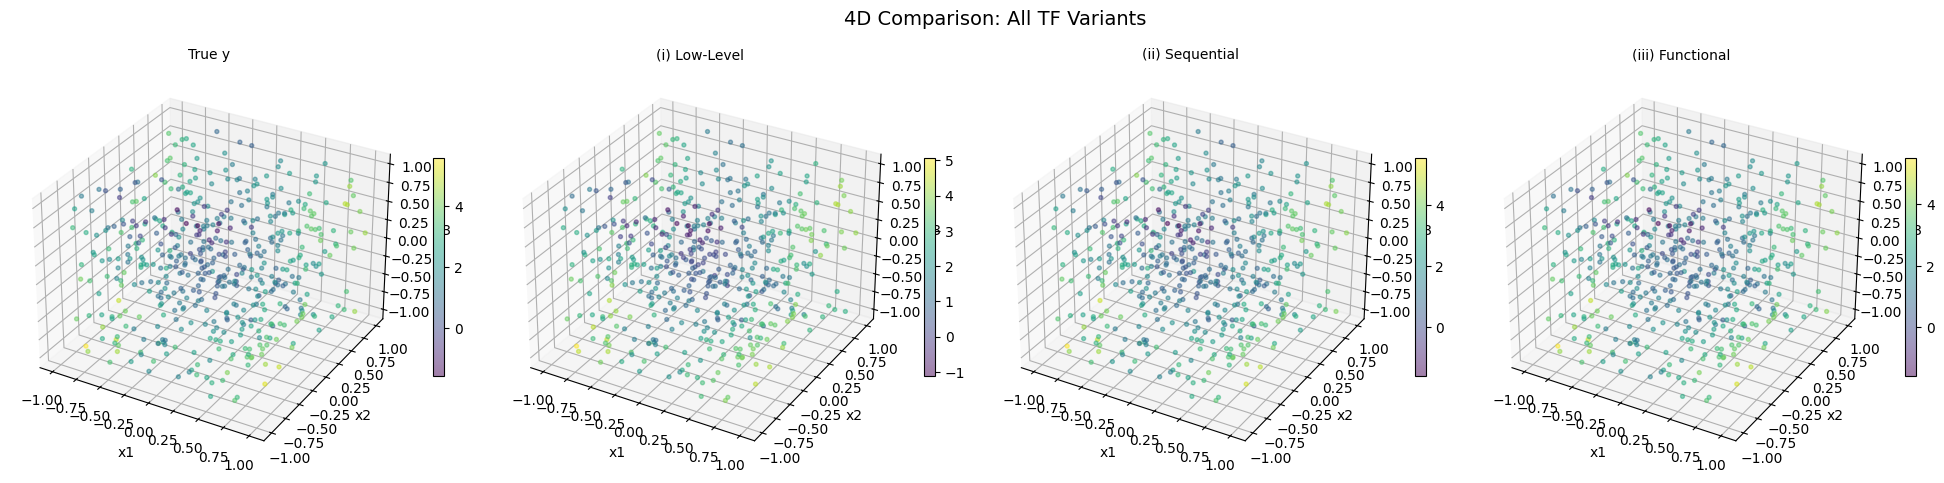

In [15]:
# --- 4D plot comparing all variants ---
fig = plt.figure(figsize=(20, 5))
datasets = [
    ('True y', y_np),
    ('(i) Low-Level', y_pred_i),
    ('(ii) Sequential', y_pred_ii),
    ('(iii) Functional', y_pred_iii),
]

for idx, (title, data) in enumerate(datasets):
    ax = fig.add_subplot(1, 4, idx+1, projection='3d')
    sc = ax.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                    c=np.array(data).flatten(), cmap='viridis',
                    alpha=0.5, s=8)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
    ax.set_title(title, fontsize=10)
    plt.colorbar(sc, ax=ax, shrink=0.5)

plt.suptitle('4D Comparison: All TF Variants', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

| Part | API Level | Pros | Cons |
|------|-----------|------|------|
| **(i)** | `tf.Variable` + `GradientTape` | Full control, educational | Verbose, error-prone |
| **(ii)** | `keras.Sequential` | Clean, fast to prototype | Limited to linear stacks |
| **(iii)** | `keras.Functional` | Flexible topology, shareable | Slightly more boilerplate than Sequential |

All three achieve comparable performance on this regression task. The choice depends on the complexity of the model topology and the level of control needed.